In [1]:
import os
import random
from PIL import Image
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img_dir = r'C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\imagens-alemanha\img_dir\train'
ann_dir = r'C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\imagens-alemanha\annot_dir\train_segmentadas'

In [7]:
img_files = sorted([f for f in os.listdir(img_dir) if f.endswith('.bmp')])
ann_files = sorted([f for f in os.listdir(ann_dir) if f.endswith('.nii.gz')])

print(f'Total de imagens: {len(img_files)}')
print(f'Total de anotações: {len(ann_files)}')

Total de imagens: 221
Total de anotações: 215


In [15]:
img_basenames = set(os.path.splitext(f)[0] for f in img_files)

len(img_basenames)

221

In [16]:
ann_basenames = set(f.replace(".nii.gz", "") for f in ann_files)

len(ann_basenames)

215

In [19]:
missing_annots = img_basenames - ann_basenames
print(f"Imagens sem anotação: {len(missing_annots)}")
for name in sorted(missing_annots):
    print(name + ".bmp")

Imagens sem anotação: 6
2022_03_21_11_02_58_22.bmp
2022_03_21_11_02_58_31.bmp
2022_03_21_11_02_58_89.bmp
2022_03_21_11_03_05_20.bmp
2022_03_21_11_03_05_66.bmp
2022_03_21_11_03_11_35.bmp


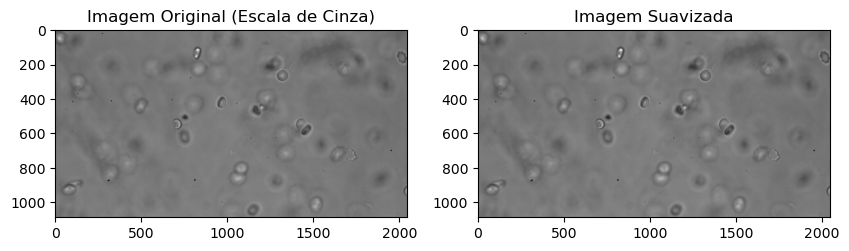

In [22]:
import cv2
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from skimage import io, color, filters, morphology

# Carregar uma imagem .bpm (assumindo que 'imagem_celula.bmp' é o nome do seu arquivo)
# OpenCV é bom para carregar .bmp e já lida com escala de cinza se a imagem for.
img_path = r'C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\imagens-alemanha\img_dir\train\2022_03_21_11_02_58_05.bmp'
image_bgr = cv2.imread(img_path)

if image_bgr is None:
    print(f"Erro: Não foi possível carregar a imagem em {img_path}")
else:
    # Converter para escala de cinza se a imagem for colorida (alguns .bpm podem ser)
    # Se já for em escala de cinza, cv2.imread pode carregá-la como uma imagem de 1 canal.
    if len(image_bgr.shape) == 3: # Se tem 3 canais (BGR)
        gray_image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    else: # Já é escala de cinza
        gray_image = image_bgr
    
    # Opcional: Aplicar um filtro de ruído (ex: filtro Gaussiano) para suavizar
    blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Imagem Original (Escala de Cinza)")
    plt.imshow(gray_image, cmap='gray')
    plt.subplot(1, 2, 2)
    plt.title("Imagem Suavizada")
    plt.imshow(blurred_image, cmap='gray')
    plt.show()

Limiar de Otsu calculado: 92.0


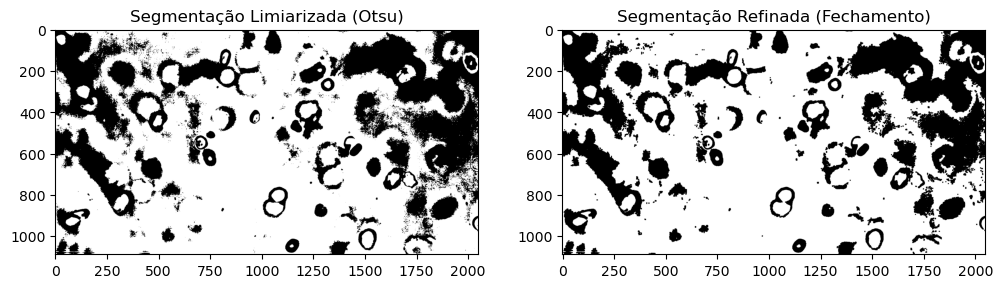

In [23]:
# Aplicar limiarização de Otsu
# Retorna o limiar e a imagem binária limiarizada
thresh_value, cells_thresholded = cv2.threshold(blurred_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f"Limiar de Otsu calculado: {thresh_value}")

# Para algumas imagens, as células podem ser mais escuras que o fundo ou vice-versa.
# Você pode precisar inverter a imagem binária se o fundo for branco e as células pretas.
# cells_thresholded = cv2.bitwise_not(cells_thresholded) # Descomente se precisar inverter

# Operações morfológicas para refinar a segmentação (opcional, mas recomendado)
# Fechamento: primeiro dilata, depois erode para fechar pequenos buracos nas células
kernel = np.ones((5,5), np.uint8)
cells_segmented = cv2.morphologyEx(cells_thresholded, cv2.MORPH_CLOSE, kernel)

# Abertura: primeiro erode, depois dilata para remover pequenos objetos (ruído)
# cells_segmented = cv2.morphologyEx(cells_segmented, cv2.MORPH_OPEN, kernel)


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Segmentação Limiarizada (Otsu)")
plt.imshow(cells_thresholded, cmap='gray')
plt.subplot(1, 2, 2)
plt.title("Segmentação Refinada (Fechamento)")
plt.imshow(cells_segmented, cmap='gray')
plt.show()

Atenção: A máscara de malária e a imagem original têm dimensões diferentes.
Dimensão Imagem: (1088, 2048), Dimensão Máscara: (2048, 1088)


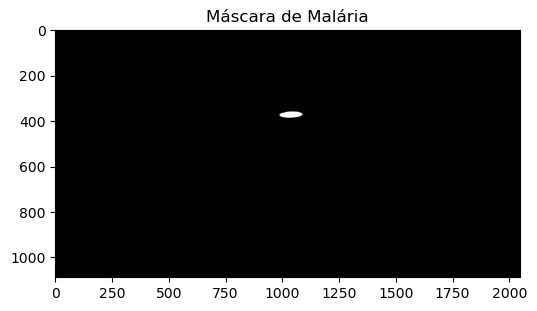

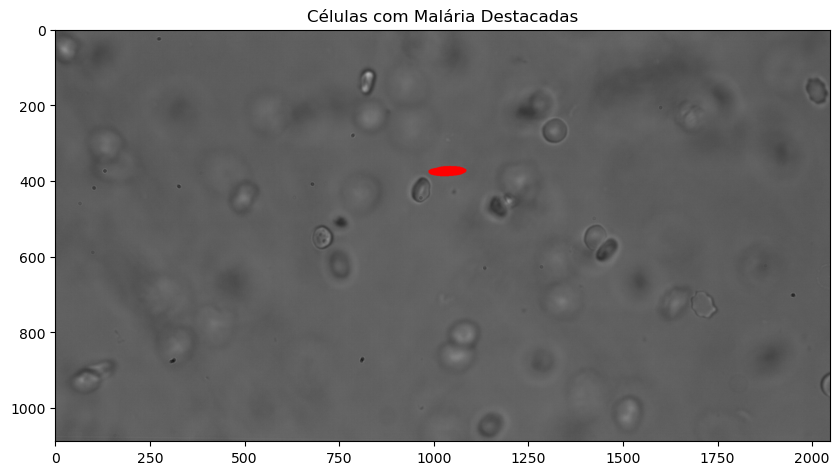

In [26]:
# Carregar a máscara .nii.gz (assumindo 'mascara_malaria.nii.gz')
mask_path = r'C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\imagens-alemanha\annot_dir\train_segmentadas\2022_03_21_11_02_58_05.nii.gz'
try:
    nifti_mask = nib.load(mask_path)
    malaria_mask = nifti_mask.get_fdata()

    # As máscaras .nii.gz podem ter mais de 2 dimensões ou tipos de dados diferentes.
    # Ajuste para a dimensão correta e tipo de dado (geralmente float, converter para int/bool)
    # Se a máscara for 3D e você tiver imagens 2D, pode ser necessário selecionar uma fatia.
    if malaria_mask.ndim > 2:
        # Exemplo: pegando a primeira fatia se for um volume
        malaria_mask_2d = malaria_mask[:, :, 0]
    else:
        malaria_mask_2d = malaria_mask
    
    # Converter a máscara para booleano ou int (0 ou 1)
    malaria_mask_binary = (malaria_mask_2d > 0).astype(np.uint8) * 255 # Para visualização como imagem 0-255

    # Certifique-se de que a máscara tem as mesmas dimensões da imagem original
    if malaria_mask_binary.shape != gray_image.shape:
        print("Atenção: A máscara de malária e a imagem original têm dimensões diferentes.")
        print(f"Dimensão Imagem: {gray_image.shape}, Dimensão Máscara: {malaria_mask_binary.shape}")
        # Redimensionar a máscara se necessário (interpolação cv2.INTER_NEAREST para máscaras)
        malaria_mask_binary = cv2.resize(malaria_mask_binary, (gray_image.shape[1], gray_image.shape[0]), interpolation=cv2.INTER_NEAREST)


    # Visualizar a máscara de malária
    plt.figure(figsize=(6, 6))
    plt.title("Máscara de Malária")
    plt.imshow(malaria_mask_binary, cmap='gray')
    plt.show()

    # Onde a máscara é 1 (ou 255 para uint8), a célula está infectada.
    # Você pode sobrepor esta máscara na imagem original ou na imagem segmentada.

    # Exemplo de sobreposição: Criar uma imagem onde células infectadas são destacadas
    # Criar uma imagem colorida a partir da imagem em escala de cinza para visualização de sobreposição
    image_display = cv2.cvtColor(gray_image, cv2.COLOR_GRAY2BGR)

    # Definir uma cor para as regiões infectadas (ex: vermelho)
    red_color = [0, 0, 255] # BGR para OpenCV

    # Aplicar a cor vermelha onde a máscara de malária é True
    image_display[malaria_mask_binary > 0] = red_color


    plt.figure(figsize=(10, 8))
    plt.title("Células com Malária Destacadas")
    plt.imshow(cv2.cvtColor(image_display, cv2.COLOR_BGR2RGB)) # Converter para RGB para matplotlib
    plt.show()

except FileNotFoundError:
    print(f"Erro: Máscara de malária não encontrada em {mask_path}")
except Exception as e:
    print(f"Ocorreu um erro ao carregar ou processar a máscara de malária: {e}")

In [ ]:
for img_file in img_files:
    # Montar caminho da imagem
    img_path = os.path.join(img_dir, img_file)

    # Procurar a anotação correspondente (baseando no nome)
    base_name = os.path.splitext(img_file)[0]  # tira .bmp
    ann_file = base_name + '.nii.gz'
    ann_path = os.path.join(ann_dir, ann_file)

    if not os.path.exists(ann_path):
        print(f'Anotação não encontrada para {img_file}')
        continue

    # Abrir imagem
    img = np.array(Image.open(img_path))

    # Abrir anotação
    ann = nib.load(ann_path).get_fdata()

    # Se for uma máscara 3D, selecionar a fatia central
    if ann.ndim == 3:
        slice_index = ann.shape[2] // 2
        mask = ann[:, :, slice_index]
    else:
        mask = ann  # se for 2D

    # Plotar
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.imshow(mask, cmap='Reds', alpha=0.4)  # Sobreposição
    plt.title(base_name)
    plt.axis('off')
    plt.show()

    # (Opcional) Salvar a imagem com a máscara sobreposta
    # output_path = os.path.join('saida', base_name + '_overlay.png')
    # plt.savefig(output_path, bbox_inches='tight')
    # plt.close()

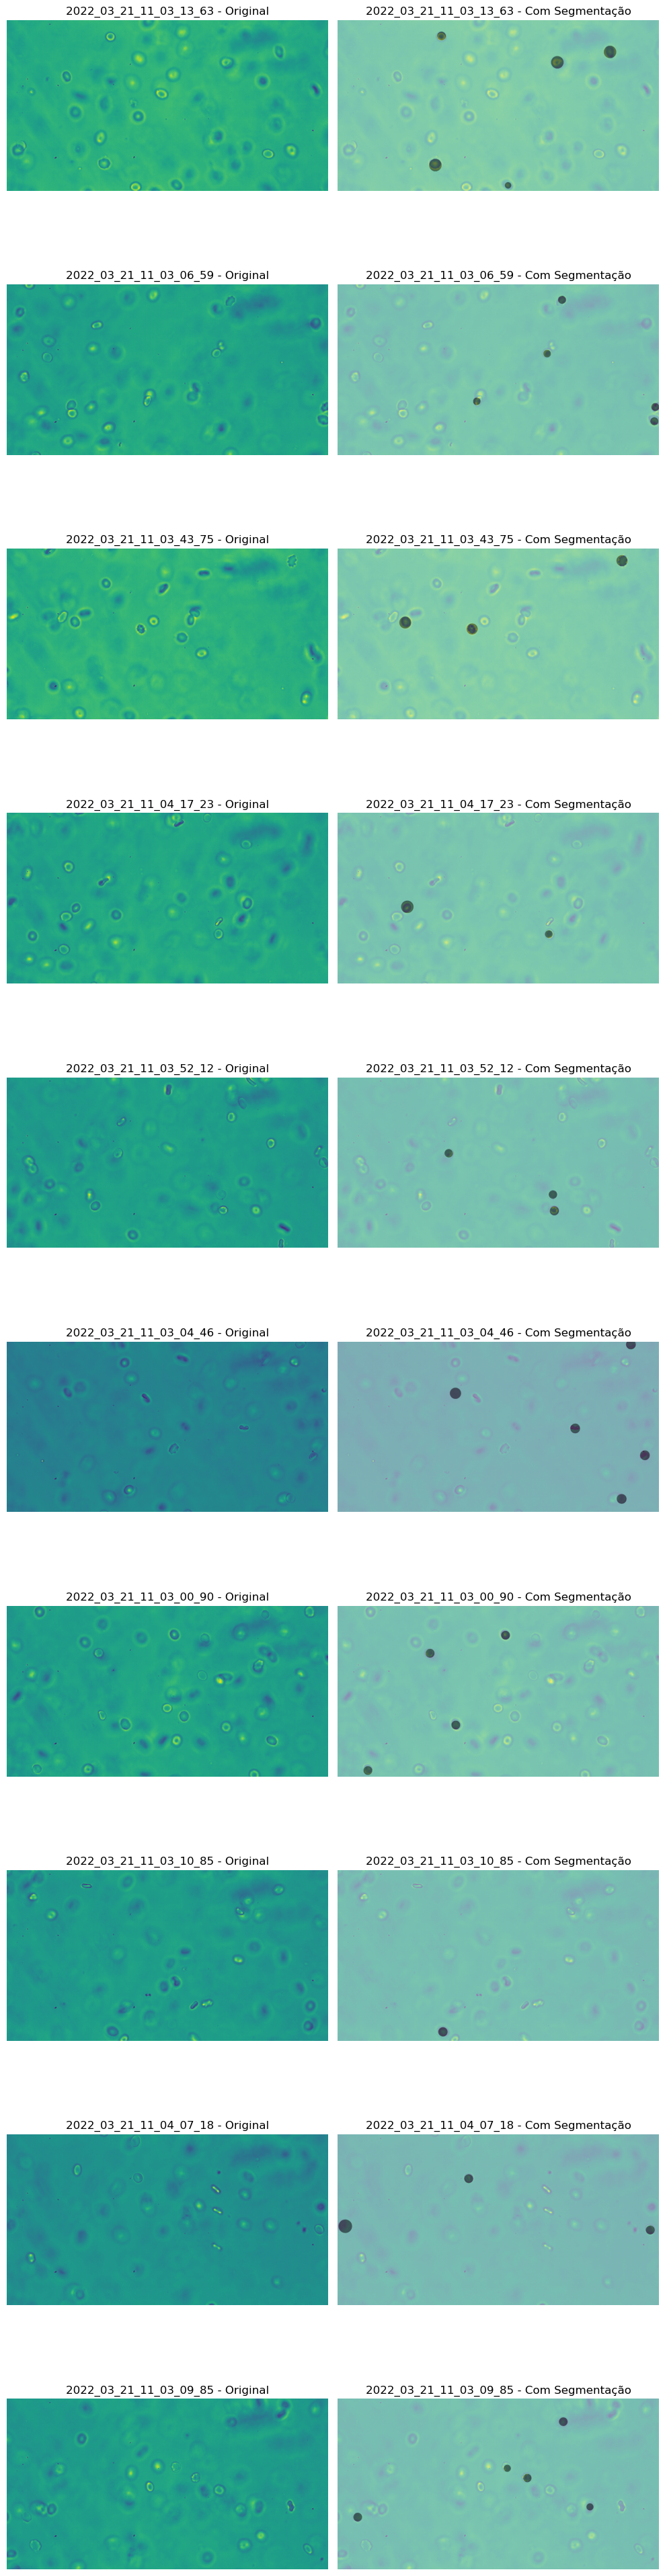

In [17]:
sample_files = random.sample(img_files, 10)

# Criar figura com 10 linhas e 2 colunas
fig, axes = plt.subplots(nrows=10, ncols=2, figsize=(10, 40))

linha = 0  # Controle das linhas no grid

for img_file in sample_files:
    try:
        # Caminhos dos arquivos
        img_path = os.path.join(img_dir, img_file)
        base_name = os.path.splitext(img_file)[0]
        ann_path = os.path.join(ann_dir, base_name + '.nii.gz')

        # Abrir imagem
        img = np.array(Image.open(img_path))

        # Abrir anotação
        ann = nib.load(ann_path).get_fdata()

        # Verificar se é 3D e pegar a fatia central
        if ann.ndim == 3:
            slice_index = ann.shape[2] // 2
            mask = ann[:, :, slice_index]
        else:
            mask = ann

        # ✅ Corrigir rotação da segmentação
        mask = np.transpose(mask)  # Corrige eixos (XY)
        #mask = np.flip(mask, axis=1)  # Flip vertical para alinhar corretamente
        #mask = np.rot90(mask, k=2)

        # Plotar imagem original
        axes[linha, 0].imshow(img)
        axes[linha, 0].set_title(f'{base_name} - Original')
        axes[linha, 0].axis('off')

        # Plotar imagem com a segmentação sobreposta
        axes[linha, 1].imshow(img)
        axes[linha, 1].imshow(mask, cmap='Reds', alpha=0.4)
        axes[linha, 1].set_title(f'{base_name} - Com Segmentação')
        axes[linha, 1].axis('off')

        linha += 1  # Avança para próxima linha do grid

    except FileNotFoundError:
        print(f'Anotação não encontrada para {img_file}. Pulando...')
    except Exception as e:
        print(f'Erro ao processar {img_file}: {e}. Pulando...')

plt.tight_layout()
plt.show()